 # Problem Statement (Telecom Domain) :
    we will predict :
        Customer Monthly Chnages / Revenue (Regression Problem)
    ----> Based on customer Usages , Tenure , services etc 

In [1]:
# Import all Imp libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler

# models
from sklearn.linear_model import LinearRegression , Ridge , Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# metrics
from sklearn.metrics import r2_score, mean_squared_error 
# pipe line
from sklearn.pipeline import Pipeline

In [3]:
# Load dataset :
df=pd.read_csv('Telco-Customer-Churn.csv',index_col='customerID')
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No


In [4]:
# BASIC EDA :
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null 

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.sample(4)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
4672-FOTSD,Male,0,No,No,12,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Month-to-month,Yes,Electronic check,67.25,832.3,No
4597-NUCQV,Male,1,No,No,24,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,101.25,2440.15,Yes
0946-FKYTX,Male,0,No,No,52,No,No phone service,DSL,No,Yes,No,No,No,No,One year,No,Mailed check,30.10,1623.4,No
7008-LZVOZ,Male,0,Yes,Yes,66,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),25.30,1672.35,No


In [19]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [20]:
df.select_dtypes([int,float])

,SeniorCitizen,tenure,MonthlyCharges
customerID,,,
7590-VHVEG,0,1,29.85
5575-GNVDE,0,34,56.95
3668-QPYBK,0,2,53.85
7795-CFOCW,0,45,42.30
9237-HQITU,0,2,70.70
...,...,...,...
6840-RESVB,0,24,84.80
2234-XADUH,0,72,103.20
4801-JZAZL,0,11,29.60


In [21]:
df.select_dtypes('object')

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
5575-GNVDE,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,1889.5,No
3668-QPYBK,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,108.15,Yes
7795-CFOCW,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),1840.75,No
9237-HQITU,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6840-RESVB,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,1990.5,No
2234-XADUH,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),7362.9,No
4801-JZAZL,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,346.45,No


In [23]:
for i in df['TotalCharges']:
    if float(i)==float:
        pass
    else:
        print(i)

29.85
1889.5
108.15
1840.75
151.65
820.5
1949.4
301.9
3046.05
3487.95
587.45
326.8
5681.1
5036.3
2686.05
7895.15
1022.95
7382.25
528.35
1862.9
39.65
202.25
20.15
3505.1
2970.3
1530.6
4749.15
30.2
6369.45
1093.1
6766.95
181.65
1874.45
20.2
45.25
7251.7
316.9
3548.3
3549.25
1105.4
475.7
4872.35
418.25
4861.45
981.45
3906.7
97
144.15
4217.8
4254.1
3838.75
1426.4
1752.65
633.3
4456.35
1752.55
6311.2
7076.35
894.3
7853.7
4707.1
5450.7
2962
957.1
857.25
244.1
3650.35
2497.2
930.9
887.35
49.05
1090.65
7099
1424.6
177.4
6139.5
2688.85
482.25
2111.3
1216.6
79.35
565.35
496.9
4327.5
973.35
918.75
2215.45
1057
927.1
1009.25
2570.2
74.7
5714.25
7107
7459.05
927.35
4748.7
113.85
1107.2
2514.5
20.2
19.45
3605.6
3027.25
7611.85
100.2
7303.05
927.65
3921.3
1363.25
5238.9
3042.25
3954.1
2868.15
3423.5
248.4
1126.35
1064.65
835.15
2151.6
5515.45
112.75
229.55
350.35
62.9
3027.65
2135.5
1723.95
19.75
3985.35
1215.65
1502.65
3260.1
35.45
81.25
1188.2
1778.5
1277.75
1170.55
70.45
6425.65
563.65
5971.25
528

ValueError: could not convert string to float: ' '

In [24]:
df['TotalCharges']=df['TotalCharges'].replace(' ',np.nan)

In [28]:
df['TotalCharges']=df['TotalCharges'].astype('float')

In [32]:
numerical_df=df.select_dtypes([int,float])
object_df=df.select_dtypes('object')

# Convert all Categorical Column into an numberical column
### label encoding


In [37]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
object_df=object_df.apply(le.fit_transform)
object_df

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
customerID,,,,,,,,,,,,,,,,
7590-VHVEG,0,1,0,0,1,0,0,2,0,0,0,0,0,1,2,0
5575-GNVDE,1,0,0,1,0,0,2,0,2,0,0,0,1,0,3,0
3668-QPYBK,1,0,0,1,0,0,2,2,0,0,0,0,0,1,3,1
7795-CFOCW,1,0,0,0,1,0,2,0,2,2,0,0,1,0,0,0
9237-HQITU,0,0,0,1,0,1,0,0,0,0,0,0,0,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6840-RESVB,1,1,1,1,2,0,2,0,2,2,2,2,1,1,3,0
2234-XADUH,0,1,1,1,2,1,0,2,2,0,2,2,1,1,1,0
4801-JZAZL,0,1,1,0,1,0,2,0,0,0,0,0,0,1,2,0


In [39]:
df=pd.concat([numerical_df,object_df],axis=1)
df.to_excel('Telecom.xlsx')

In [50]:
df.dropna(subset=['TotalCharges'],axis=0,inplace=True)

# EDA :
    1. Univariate Analysis :
        - Numeircal 
        - Categorical 

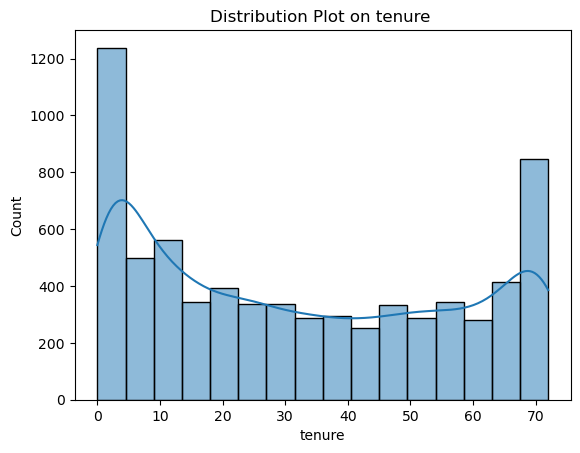

In [44]:
#  Numeircal 
sns.histplot(df['tenure'],kde=True)   
plt.title('Distribution Plot on tenure ')
plt.show()

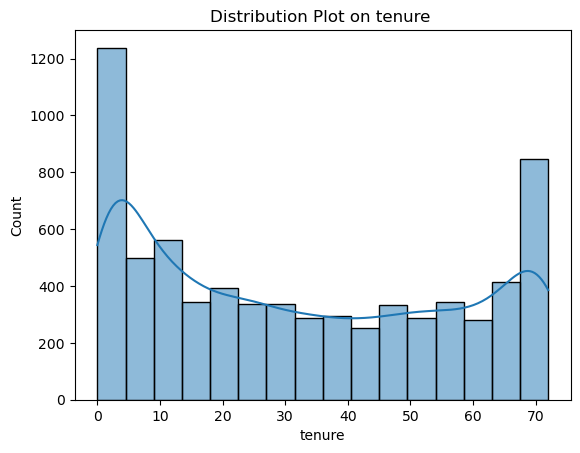

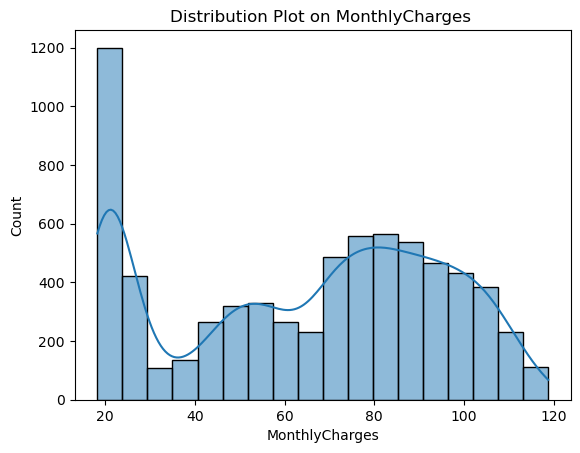

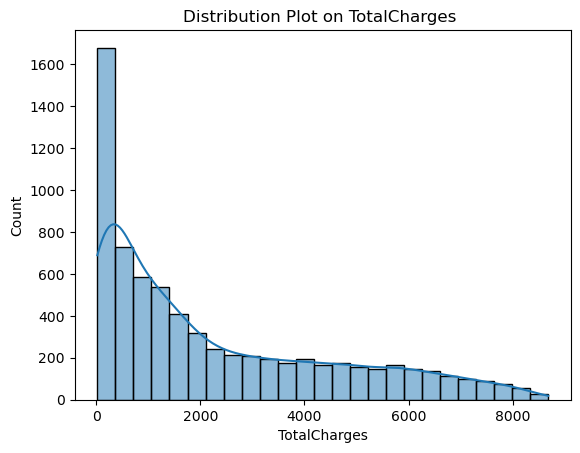

In [46]:
for i in ['tenure','MonthlyCharges','TotalCharges']:
    sns.histplot(df[i],kde=True)   
    plt.title(f'Distribution Plot on {i} ')
    plt.show()

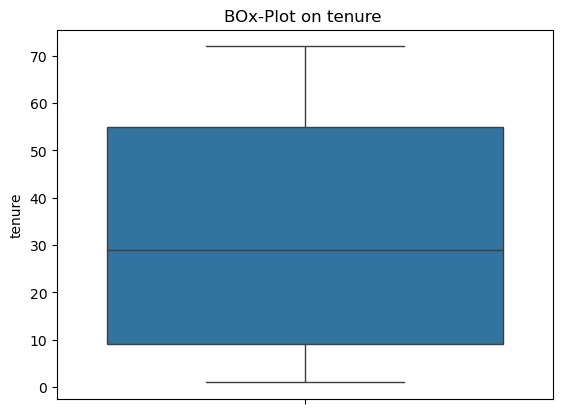

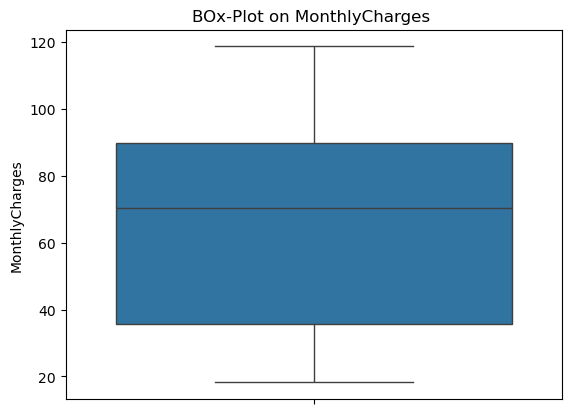

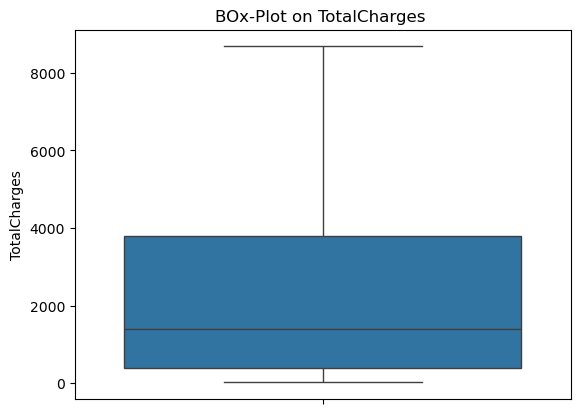

In [52]:
for i in ['tenure','MonthlyCharges','TotalCharges']:
    sns.boxplot(df[i])   
    plt.title(f'BOx-Plot on {i} ')
    plt.show()

In [61]:
# Univariate Analysis on Categorical Columns
for i in object_df.columns:
    print(df[i].value_counts(normalize=True)*100)
    print()

gender
1    50.469283
0    49.530717
Name: proportion, dtype: float64

Partner
0    51.749147
1    48.250853
Name: proportion, dtype: float64

Dependents
0    70.150739
1    29.849261
Name: proportion, dtype: float64

PhoneService
1    90.32992
0     9.67008
Name: proportion, dtype: float64

MultipleLines
0    48.137088
2    42.192833
1     9.670080
Name: proportion, dtype: float64

InternetService
1    44.027304
0    34.357224
2    21.615472
Name: proportion, dtype: float64

OnlineSecurity
0    49.729807
2    28.654721
1    21.615472
Name: proportion, dtype: float64

OnlineBackup
0    43.899317
2    34.485210
1    21.615472
Name: proportion, dtype: float64

DeviceProtection
0    43.998862
2    34.385666
1    21.615472
Name: proportion, dtype: float64

TechSupport
0    49.374289
2    29.010239
1    21.615472
Name: proportion, dtype: float64

StreamingTV
0    39.945961
2    38.438567
1    21.615472
Name: proportion, dtype: float64

StreamingMovies
0    39.547782
2    38.836746
1    21.6

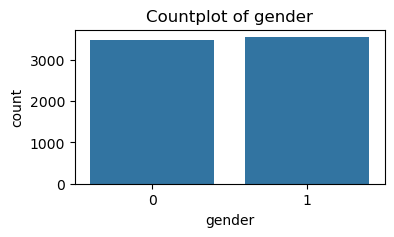

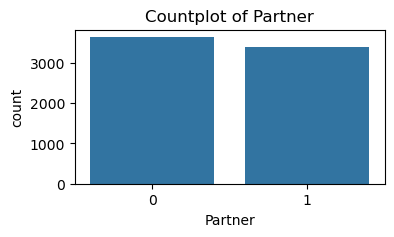

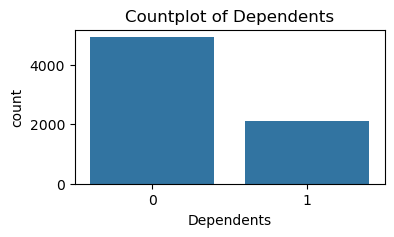

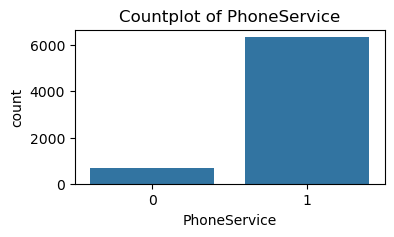

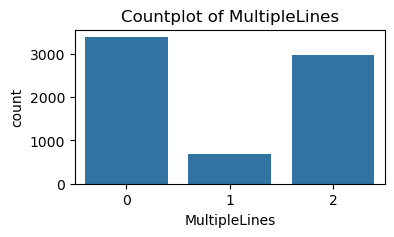

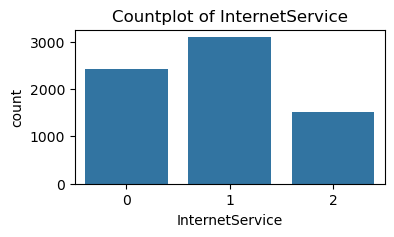

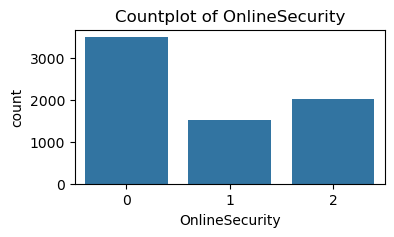

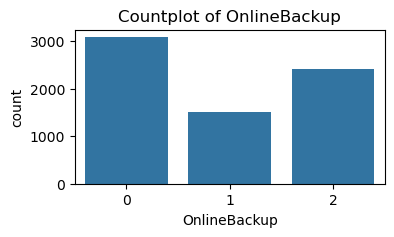

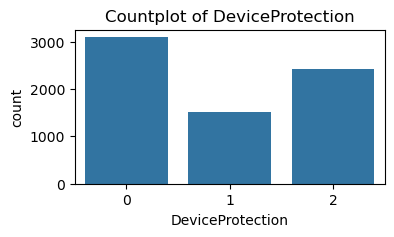

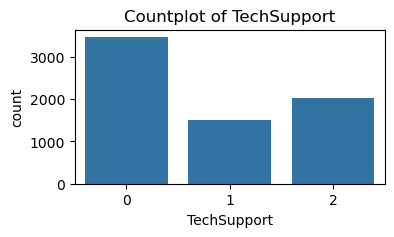

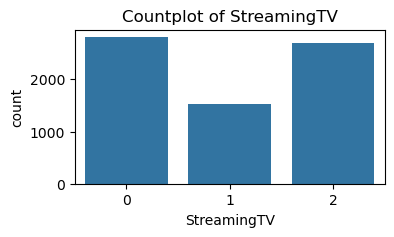

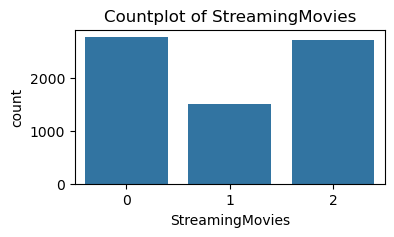

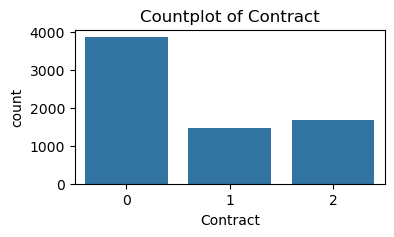

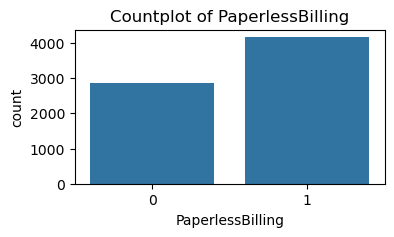

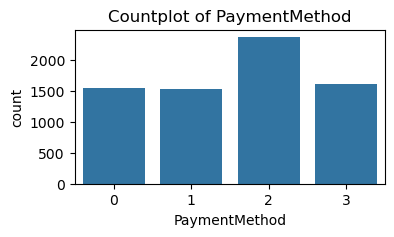

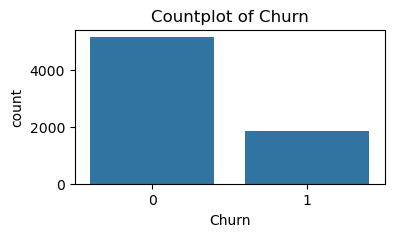

In [65]:
# Countplot 
for i in object_df.columns:
    plt.figure(figsize=(4,2))
    sns.countplot(x=i,data=df)
    plt.title(f'Countplot of {i}')
    plt.show()

# Bivariate Analysis :
    - Numerical
    - Categorical

    A. NUM vs NUM
    B. NUM vs CAT
    C. CAT VS CAT
    

In [67]:
# Corr 
df[['tenure','MonthlyCharges','TotalCharges']].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.246862,0.825880
MonthlyCharges,0.246862,1.000000,0.651065
TotalCharges,0.825880,0.651065,1.000000


In [68]:
object_df.columns


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

<Axes: xlabel='Contract', ylabel='tenure'>

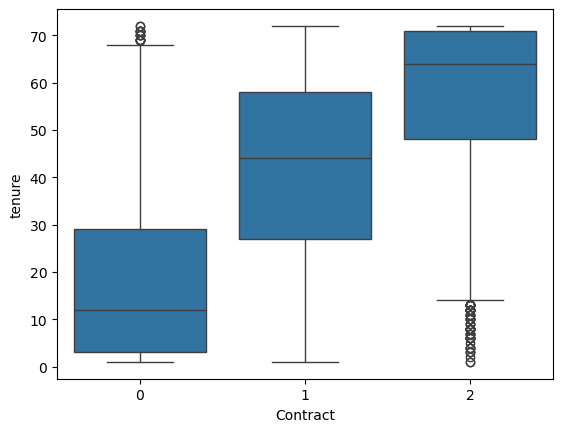

In [69]:
# cat vs cont
sns.boxplot(x=df['Contract'],y=df['tenure'])

In [71]:
# Define Feature and Target
x=df.drop('MonthlyCharges',axis=1)
y=df['MonthlyCharges']

In [72]:
# train test split 
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [73]:
# Apply SCALING :
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [74]:
# Train multiple Regression Model
# 1. Linear Regression 
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred_lr=lr.predict(x_test)


In [75]:
# 2. Ridge regression 
ridge=Ridge()
ridge.fit(x_train,y_train)
y_pred_ridge=ridge.predict(x_test)

In [76]:
# 3. Lasso 
lasso=Lasso()
lasso.fit(x_train,y_train)
y_pred_lasso=lasso.predict(x_test)

In [77]:
# 4. Decision tree
dt=DecisionTreeRegressor()
dt.fit(x_train,y_train)
y_pred_dt=dt.predict(x_test)

In [78]:
# 5. RFT
rf=RandomForestRegressor()
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)

In [83]:
# Evalate all Model
def evaluate(y_test,y_pred,model_name):
    print(f'{model_name}')
    print(f'score = {r2_score(y_test,y_pred)}')

evaluate(y_test,y_pred_lr,'LinearRegression')
evaluate(y_test,y_pred_ridge,'Ridge')
evaluate(y_test,y_pred_lasso,'Lasso')
evaluate(y_test,y_pred_dt,'DT')
evaluate(y_test,y_pred_rf,'RF')

LinearRegression
score = 0.8105235496048195
Ridge
score = 0.8105165580344679
Lasso
score = 0.7929010278873609
DT
score = 0.9962009226378793
RF
score = 0.9980861478886095


In [84]:
# Usually Random Forest gives the best performance

In [87]:
# Final Model ---> Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor())
])

pipeline.fit(x_train, y_train)

y_pred_pipeline = pipeline.predict(x_test)

print("Final Pipeline Model")
print("R2 Score:", r2_score(y_test, y_pred_pipeline))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_pipeline)))

Final Pipeline Model
R2 Score: 0.9980772582623443
RMSE: 1.3035593165602568


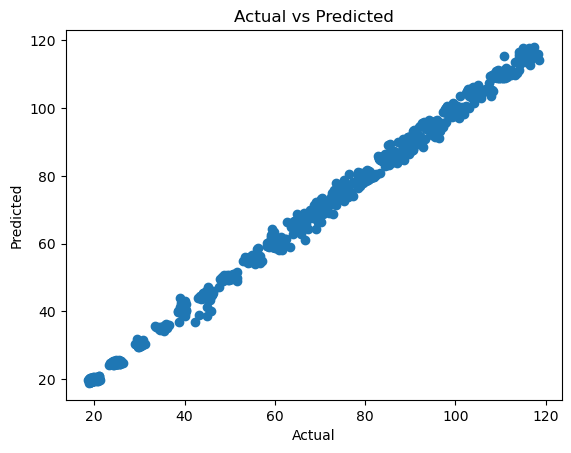

In [89]:
plt.scatter(y_test, y_pred_pipeline)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [90]:
# Create Pickle file 
import pickle
with open('telecom_model_rf.pkl','wb') as f:
    pickle.dump(pipeline,f)

In [91]:
# SAVE LABEL ENCODE
with open('lable_encoder_telecom.pkl','wb') as f:
    pickle.dump(le,f)